In [27]:
from trachoma.trachoma_functions import *
import multiprocessing
from joblib import Parallel, delayed
num_cores = multiprocessing.cpu_count()

#############################################################################################################################
#############################################################################################################################

# initialize parameters, sim_params, and demography

params = {'N': 2500,
          'av_I_duration' : 2,
          'av_ID_duration':200/7,
          'inf_red':0.45,
          'min_ID':11, #Parameters relating to duration of infection period, including ID period
          'av_D_duration':300/7,
          'min_D':1, #Parameters relating to duration of disease period
          'v_1':1,
          'v_2':2.6,
          'phi':1.4,
          'epsilon':0.5,#Parameters relating to lambda function- calculating force of infection
          #Parameters relating to MDA
          'MDA_Cov':0.8,
          'MDA_Eff': 0.85, # Efficacy of treatment
          'rho':0.3,
          'nweeks_year':52,
          'babiesMaxAge':0.5, #Note this is years, need to check it converts to weeks later
          'youngChildMaxAge':9,#Note this is years, need to check it converts to weeks later
          'olderChildMaxAge':15, #Note this is years, need to check it converts to weeks later
          'b1':1,#this relates to bacterial load function
          'ep2':0.114,
          'n_inf_sev':38,
          'TestSensitivity': 0.96,
          'TestSpecificity': 0.965,
          'SecularTrendIndicator': 0,
          'SecularTrendYearlyBetaDecrease': 0.01,
          'vacc_prob_block_transmission':  0, 
          'vacc_reduce_bacterial_load': 0, 
          'vacc_reduce_duration': 0,
          'vacc_coverage': 0,  
          'vacc_waning_length': 52 * 5}


burnin = 100*52
timesim = burnin + 21*52

sim_params = {'timesim': timesim, 
              'burnin': burnin,
              'N_MDA':5,
              'n_sim':1}


demog = {'tau': 0.0004807692, 
         'max_age': 3120,
         'mean_age': 1040}



previous_rounds = 0

# this gives the start date of the post burn-in part of the simulation. 
Start_date = date(2018,1, 1)



In [28]:
def seed_to_state(seed):
    np.random.seed(seed)
    return np.random.get_state()

# this is essentially the same as the original version of the Trachoma_Simulation function

def SimulationFunction(parameters, sim_params, demog, MDA_times, MDAData, vacc_times, seed_bump, beta):

    # Longitudinal simulations:
    # First Set initial conditions and seed infection
    

    # Set times for MDA to be carried out

   

    # Setting beta; the higher this is the higher the prevalence. 0.12 has prevalence around 20%
    #bet = np.random.uniform(size=sim_params['n_sim'], low=0.1, high=0.12)
    bet = np.ones(sim_params['n_sim']) * beta
    # Run multiple simulations
    def multiple_simulations(i):
        seed = i * seed_bump

        # Generate some random numbers
        np.random.seed(seed)
# we generate a numpy state for each simulation by saving a state. If the seed is set above, this will be consistent from run to run
        numpy_states = list(map(lambda s: seed_to_state(s), np.random.randint(2^32, size=1)))
        vals = Set_inits(params=parameters, demog=demog, sim_params = sim_params, MDAData=MDAData, numpy_state = numpy_states[0])    # Set initial conditions
        vals = Seed_infection(params=parameters, vals=vals) # Seed infection
        out = sim_Ind_MDA(params, vals, timesim, burnin, demog, bet[i], MDA_times, MDAData, vacc_times, numpy_state = numpy_states[0])
        return out

    data_store_all_sim = Parallel(n_jobs=num_cores)(delayed(multiple_simulations)(i) for i in range(sim_params['n_sim']))

    return data_store_all_sim




# analyse the runs of the simulations
# we return some aggregated results along with the raw data
def analyseResults(data, sim_params, yearToStartFit):

    True_Prev_Infection_children_1_9 = np.zeros(shape=(sim_params['timesim'] , sim_params['n_sim']))
    True_Prev_Disease_children_1_9 = np.zeros(shape=(sim_params['timesim'] , sim_params['n_sim']))
    True_Prev_Disease = np.zeros(shape=(sim_params['timesim'] , sim_params['n_sim']))
    True_Prev_Infection = np.zeros(shape=(sim_params['timesim'] , sim_params['n_sim']))
    Time = np.arange(sim_params['timesim'] )

    
    for i in range(sim_params['n_sim']):

        True_Prev_Disease[:, i] = data[i]['True_Prev_Disease'][0: sim_params['timesim']]
        True_Prev_Infection[:, i] = data[i]['True_Prev_Infection'][0: sim_params['timesim']]
        True_Prev_Infection_children_1_9[:, i] = data[i]['True_Prev_Infection_children_1_9'][0: sim_params['timesim']]
        True_Prev_Disease_children_1_9[:, i] = data[i]['True_Prev_Disease_children_1_9'][0: sim_params['timesim']]

    
    results = pd.DataFrame({'Time': yearToStartFit - sim_params['burnin']/52 + Time / 52,
                            'Mean_Disease_Children': np.mean(True_Prev_Disease_children_1_9, axis=1),
                            'Mean_Infection_Children': np.mean(True_Prev_Infection_children_1_9, axis=1),
                            'Mean_Disease_All': np.mean(True_Prev_Disease, axis=1),
                            'Mean_Infection_All': np.mean(True_Prev_Infection, axis=1),
                            'Median_Disease_Children': np.median(True_Prev_Disease_children_1_9, axis=1),
                            'Median_Infection_Children': np.median(True_Prev_Infection_children_1_9, axis=1),
                            'Median_Disease_All': np.median(True_Prev_Disease, axis=1),
                            'Median_Infection_All': np.median(True_Prev_Infection, axis=1)
                            })

    return results,True_Prev_Infection_children_1_9, True_Prev_Disease_children_1_9 , True_Prev_Disease, True_Prev_Infection




# function to get the MDA data for the specified coverage file
def get_MDA_data(coverageFileName):
    MDAData = readPlatformData(coverageFileName, "MDA")
    MDA_dates = getInterventionDates(MDAData)
    MDA_times = get_Intervention_times(MDA_dates, Start_date, sim_params['burnin'])
    return MDAData, MDA_times


In [33]:
vacc_times = []
seed = 100
beta = 0.15
yearToStartFit = 2018


In [34]:

MDAData1, MDA_times1 = get_MDA_data("scen1_no_interruption.csv")
data1 = SimulationFunction(params, sim_params, demog, MDA_times1, MDAData1, vacc_times, seed_bump  = seed, beta = beta)
res1 = analyseResults(data1, sim_params, yearToStartFit)

MDAData2, MDA_times2 = get_MDA_data("scen1_interrupt_no_mitigation.csv")

data2 = SimulationFunction(params, sim_params, demog, MDA_times2, MDAData2, vacc_times, seed_bump  = seed, beta = beta)
res2 = analyseResults(data2, sim_params, yearToStartFit)

MDAData3, MDA_times3 = get_MDA_data("scen1_interrupt_mitigation.csv")
data3 = SimulationFunction(params, sim_params, demog, MDA_times3, MDAData3, vacc_times, seed_bump  = seed, beta = beta)
res3 = analyseResults(data3, sim_params, yearToStartFit)

In [35]:
res1[0]

,Time,Mean_Disease_Children,Mean_Infection_Children,Mean_Disease_All,Mean_Infection_All,Median_Disease_Children,Median_Infection_Children,Median_Disease_All,Median_Infection_All
0,1918.000000,0.000000,0.004717,0.0000,0.0092,0.000000,0.004717,0.0000,0.0092
1,1918.019231,0.004717,0.004717,0.0092,0.0092,0.004717,0.004717,0.0092,0.0092
2,1918.038462,0.004706,0.005882,0.0092,0.0104,0.004706,0.005882,0.0092,0.0104
3,1918.057692,0.004678,0.005848,0.0092,0.0108,0.004678,0.005848,0.0092,0.0108
4,1918.076923,0.005828,0.005828,0.0104,0.0116,0.005828,0.005828,0.0104,0.0116
...,...,...,...,...,...,...,...,...,...
6287,2038.903846,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.0000
6288,2038.923077,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.0000
6289,2038.942308,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.0000
6290,2038.961538,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.0000


Text(0.5, 1.0, 'Prevalence of disease in children 1-9')

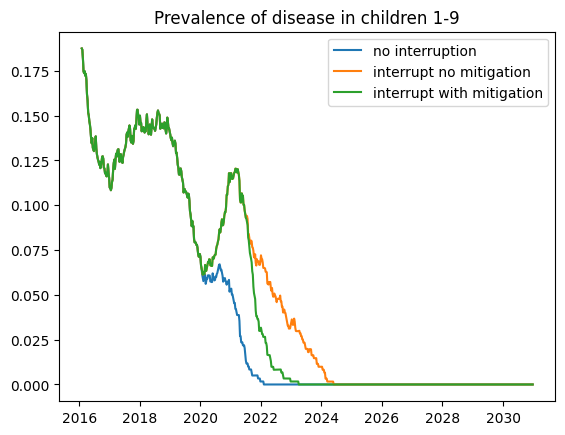

In [36]:
import matplotlib.pyplot as plt
start_year = 2018-burnin/52
plt.plot(np.array(res1[0]['Time'][(sim_params['burnin']-100):(sim_params['timesim']-416)]),np.array(res1[0]['Median_Disease_Children'][(sim_params['burnin']-100): (sim_params['timesim']-416)]))
plt.plot(np.array(res2[0]['Time'][(sim_params['burnin']-100): (sim_params['timesim']-416)]),np.array(res2[0]['Median_Disease_Children'][(sim_params['burnin']-100): (sim_params['timesim']-416)]))
plt.plot(np.array(res3[0]['Time'][(sim_params['burnin']-100): (sim_params['timesim']-416)]),np.array(res3[0]['Median_Disease_Children'][(sim_params['burnin']-100): (sim_params['timesim']-416)]))
plt.legend(['no interruption', 'interrupt no mitigation', 'interrupt with mitigation']) 
plt.title("Prevalence of disease in children 1-9")

Text(0.5, 1.0, 'Prevalence of disease in children 1-9')

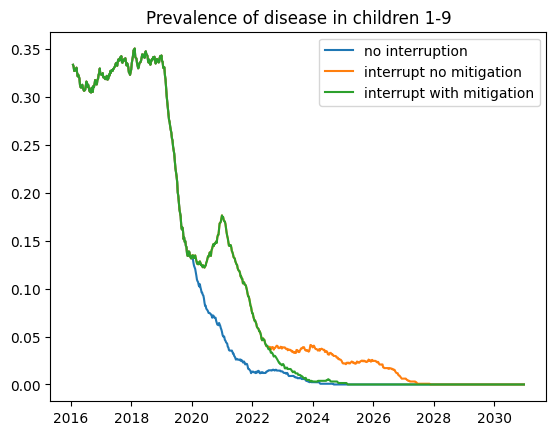

In [ ]:
import matplotlib.pyplot as plt
start_year = 2018-burnin/52
plt.plot(np.array(start_year + res1[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']]),np.array(res1[0]['Median_Disease_Children'][(sim_params['burnin']-100): sim_params['timesim']]))
plt.plot(np.array(start_year + res2[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']]),np.array(res2[0]['Median_Disease_Children'][(sim_params['burnin']-100): sim_params['timesim']]))
plt.plot(np.array(start_year + res3[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']]),np.array(res3[0]['Median_Disease_Children'][(sim_params['burnin']-100): sim_params['timesim']]))
plt.legend(['no interruption', 'interrupt no mitigation', 'interrupt with mitigation']) 
plt.title("Prevalence of disease in children 1-9")

Text(0.5, 1.0, 'Prevalence of infection in children 1-9')

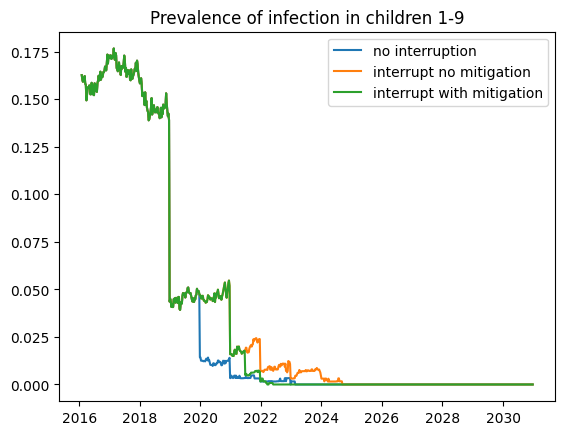

In [ ]:


plt.plot(np.array(start_year + res1[0]['Time'][(sim_params['burnin']-100):(sim_params['timesim']-416)]),np.array(res1[0]['Median_Infection_Children'][(sim_params['burnin']-100): (sim_params['timesim']-416)]))
plt.plot(np.array(start_year + res2[0]['Time'][(sim_params['burnin']-100): (sim_params['timesim']-416)]),np.array(res2[0]['Median_Infection_Children'][(sim_params['burnin']-100): (sim_params['timesim']-416)]))
plt.plot(np.array(start_year + res3[0]['Time'][(sim_params['burnin']-100): (sim_params['timesim']-416)]),np.array(res3[0]['Median_Infection_Children'][(sim_params['burnin']-100): (sim_params['timesim']-416)]))
plt.legend(['no interruption', 'interrupt no mitigation', 'interrupt with mitigation']) 
plt.title("Prevalence of infection in children 1-9")

Text(0.5, 1.0, 'Prevalence of infection in children 1-9')

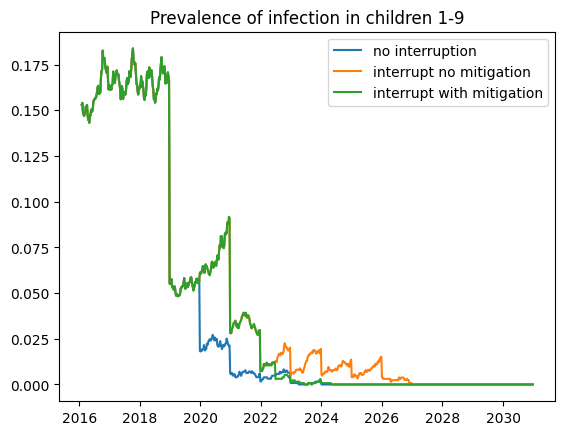

In [ ]:

plt.plot(start_year + res_no_interruption[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']], res_no_interruption[0]['Median_Infection_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.plot(start_year + res_no_interruption[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']], res_interrupt_no_mitigation[0]['Median_Infection_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.plot(start_year + res_no_interruption[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']], res_interrupt_mitigation[0]['Median_Infection_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.legend(['no interruption', 'interrupt no mitigation', 'interrupt with mitigation']) 
plt.title("Prevalence of infection in children 1-9")

In [ ]:
from trachoma.trachoma_functions import *
import numpy as np
import copy
# initialize parameters, sim_params, and demography

params = {'N': 2500,
          'av_I_duration' : 2,
          'av_ID_duration':200/7,
          'inf_red':0.45,
          'min_ID':11, #Parameters relating to duration of infection period, including ID period
          'av_D_duration':300/7,
          'min_D':1, #Parameters relating to duration of disease period
          'v_1':1,
          'v_2':2.6,
          'phi':1.4,
          'epsilon':0.5,#Parameters relating to lambda function- calculating force of infection
          #Parameters relating to MDA
          'MDA_Cov':0.8,
          'MDA_Eff': 0.85, # Efficacy of treatment
          'rho':0,
          'nweeks_year':52,
          'babiesMaxAge':0.5, #Note this is years, need to check it converts to weeks later
          'youngChildMaxAge':9,#Note this is years, need to check it converts to weeks later
          'olderChildMaxAge':15, #Note this is years, need to check it converts to weeks later
          'b1':1,#this relates to bacterial load function
          'ep2':0.114,
          'n_inf_sev':38,
          'TestSensitivity': 0.96,
          'TestSpecificity': 0.965,
          'SecularTrendIndicator': 0,
          'SecularTrendYearlyBetaDecrease': 0.01,
          'vacc_prob_block_transmission':  0, 
          'vacc_reduce_bacterial_load': 0, 
          'vacc_reduce_duration': 0,
          'vacc_coverage': 0,  
          'vacc_waning_length': 52 * 5}

def seed_to_state(seed):
    np.random.seed(seed)
    return np.random.get_state()

burnin = 100*52
timesim = burnin + 21*52

sim_params = {'timesim': timesim, 
              'burnin': burnin,
              'N_MDA':5,
              'n_sim':16}


demog = {'tau': 0.0004807692, 
         'max_age': 3120,
         'mean_age': 1040}

MDAData = [[2018.0, 0, 100.0, 0.1, 0, 2],
            [2019.0, 0, 0.5, 0.8, 1, 2]]
MDA_times = np.array([5200, 5252])

# Longitudinal simulations:
    # First Set initial conditions and seed infection
vals = Set_inits(params=params, demog=demog, sim_params = sim_params, MDAData=MDAData)    # Set initial conditions

vals['IndI'] = np.ones(params['N'])

def testMDAOnChildren(vals, params, MDA_times, MDAData, nMDAs, i):
    MDA_round = np.where(MDA_times == i)[0]
    propCured = []
    for runs in range(nMDAs):
        valsTest = copy.deepcopy(vals)
        valsTest['Age'] = np.zeros(params['N'])
        preMDAInf = sum(valsTest['IndI'])
        for l in range(len(MDA_round)):
            MDA_round_current = MDA_round[l]
            ageStart, ageEnd, cov, systematic_non_compliance = get_MDA_params(MDAData, MDA_round_current, valsTest)
            valsTest = check_if_we_need_to_redraw_probability_of_treatment(cov, systematic_non_compliance, valsTest)
            out = MDA_timestep_Age_range(valsTest, params, ageStart, ageEnd)
            valsTest = out[0]
            postMDAInf = sum(valsTest['IndI'])
            propCured.append((preMDAInf - postMDAInf)/preMDAInf)
    return(propCured)

nMDAs = 10
i = 5252
pc = testMDAOnChildren(vals, MDA_times, MDAData, nMDAs, i)
print(np.mean(pc)/(0.5*params['MDA_Eff'] * MDAData[1][3]))

1.0072941176470587


In [ ]:
vals['bact_load'] = bacterialLoad(range(params['N']),params = params, vals = vals)

In [ ]:
vals['bact_load']

array([1.12075212, 1.12075212, 1.12075212, ..., 1.12075212, 1.12075212,
       1.12075212])